In [1]:
import pymc as pm
import pandas as pd


In [3]:
data = pd.read_csv('/content/sample_data/wage1.txt', sep='\t')

with pm.Model() as modelo_salario:
    # Priors
    beta_0 = pm.Normal('betha_0', mu=0, sigma=10)
    beta_1 = pm.Normal('betha_1', mu=0, sigma=10)
    beta_2 = pm.Normal('betha_2', mu=0, sigma=10)
    beta_3 = pm.Normal('betha_3', mu=0, sigma=10)
    beta_4 = pm.Normal('betha_4', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=10)

    # Media
    mu = (beta_0 +
          beta_1 * data['educ'] +
          beta_2 * data['exper'] +
          beta_3 * data['expersq'] +
          beta_4 * data['female'])

    # Likelihood
    lwage_obs = pm.Normal('lwage_obs', mu=mu, sigma=sigma, observed=data['lwage'])

    # Ajuste del modelo
    trace = pm.sample(2000, return_inferencedata=True)


Output()

Output()

In [12]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,0.388,0.103,0.199,0.582,0.002,0.001,2644.0,2105.0,1.0
beta_1,0.084,0.007,0.071,0.097,0.000,0.000,2766.0,2203.0,1.0
beta_2,0.039,0.005,0.030,0.048,0.000,0.000,2501.0,2508.0,1.0
beta_3,-0.001,0.000,-0.001,-0.000,0.000,0.000,2551.0,2476.0,1.0
beta_4,-0.337,0.036,-0.403,-0.268,0.001,0.000,2962.0,2185.0,1.0
sigma,0.414,0.013,0.390,0.437,0.000,0.000,3523.0,2639.0,1.0


<Figure size 700x1400 with 0 Axes>

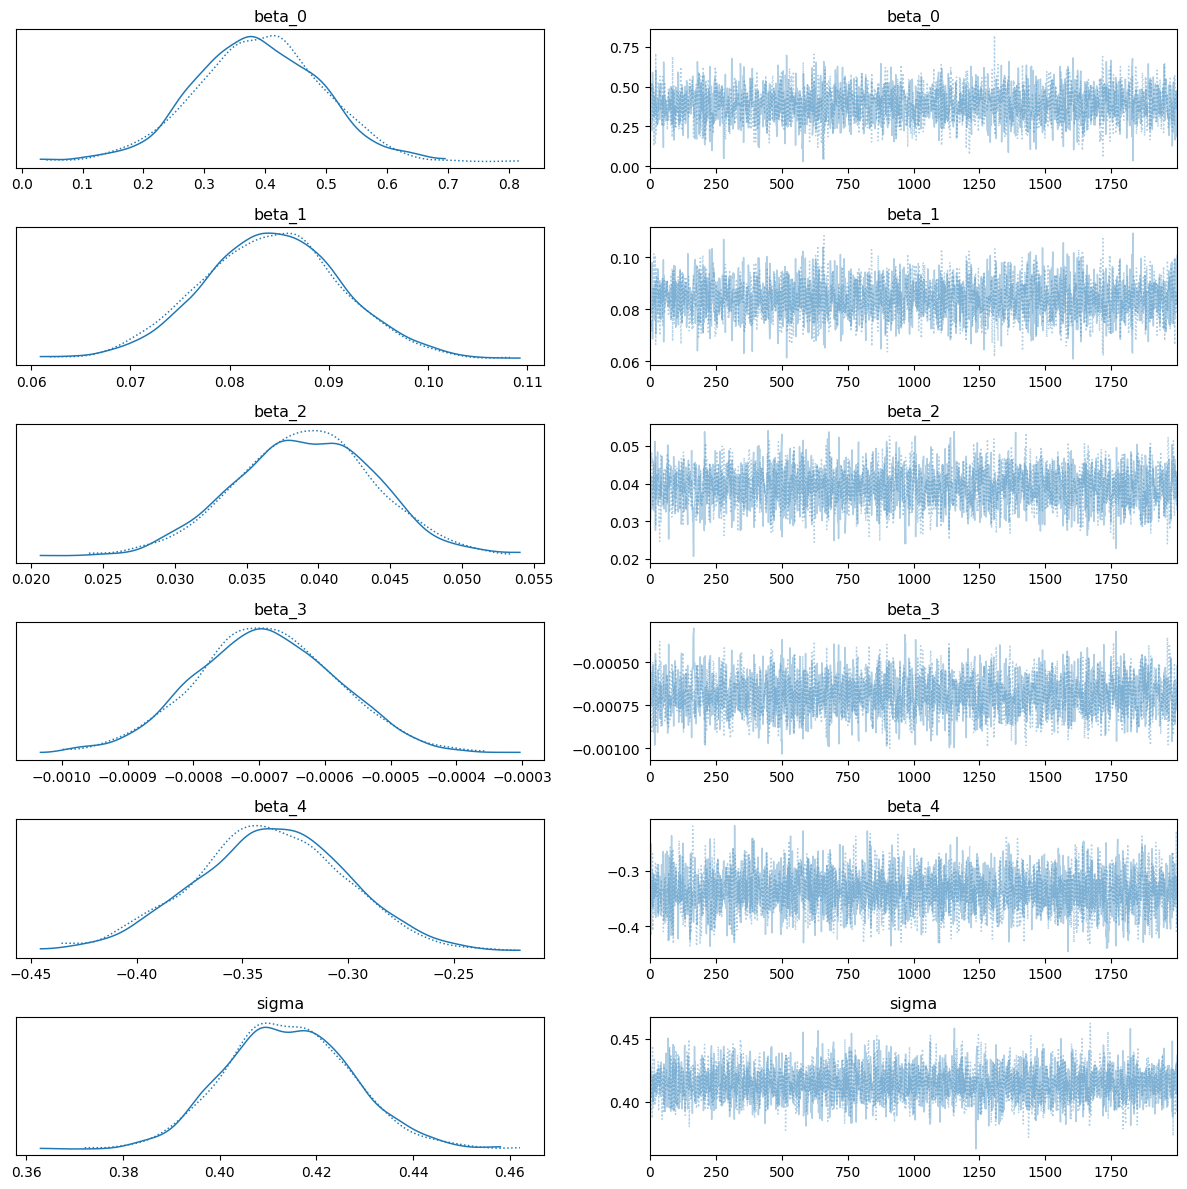

In [13]:
plt.figure(figsize=(7, 14))
pm.plot_trace(trace)
plt.tight_layout()
plt.show()

In [4]:
import arviz as az

summary = az.summary(trace, hdi_prob=0.95)
print(summary)

         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta_0  0.388  0.103     0.190      0.591      0.002    0.001    2644.0   
beta_1  0.084  0.007     0.070      0.097      0.000    0.000    2766.0   
beta_2  0.039  0.005     0.030      0.049      0.000    0.000    2501.0   
beta_3 -0.001  0.000    -0.001     -0.000      0.000    0.000    2551.0   
beta_4 -0.337  0.036    -0.408     -0.268      0.001    0.000    2962.0   
sigma   0.414  0.013     0.390      0.439      0.000    0.000    3523.0   

        ess_tail  r_hat  
beta_0    2105.0    1.0  
beta_1    2203.0    1.0  
beta_2    2508.0    1.0  
beta_3    2476.0    1.0  
beta_4    2185.0    1.0  
sigma     2639.0    1.0  


Como beta4 tiene un valor negativo **-0-337**, nos indica que la variable relacionada al genero tiene un efecto negativo en el log-salario mujeres dentro del rango de credibilidad -0.408 y -0.268

In [7]:
# Crear dos individuos
individual_1 = {'educ': 12, 'exper': 3, 'expersq': 3**2, 'female': 0}
individual_2 = {'educ': 12, 'exper': 3, 'expersq': 3**2, 'female': 1}

# simulacion
with modelo_salario:
    posterior_predictive = pm.sample_posterior_predictive(trace, var_names=['lwage_obs'])


Output()

In [9]:
print(posterior_predictive.keys())


KeysView(Inference data with groups:
	> posterior_predictive
	> observed_data)


In [10]:
print(posterior_predictive.posterior_predictive.keys())


KeysView(<xarray.Dataset> Size: 17MB
Dimensions:          (chain: 2, draw: 2000, lwage_obs_dim_2: 526)
Coordinates:
  * chain            (chain) int64 16B 0 1
  * draw             (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
  * lwage_obs_dim_2  (lwage_obs_dim_2) int64 4kB 0 1 2 3 4 ... 522 523 524 525
Data variables:
    lwage_obs        (chain, draw, lwage_obs_dim_2) float64 17MB 1.33 ... 1.296
Attributes:
    created_at:                 2024-11-07T20:34:33.692532+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.17.0)


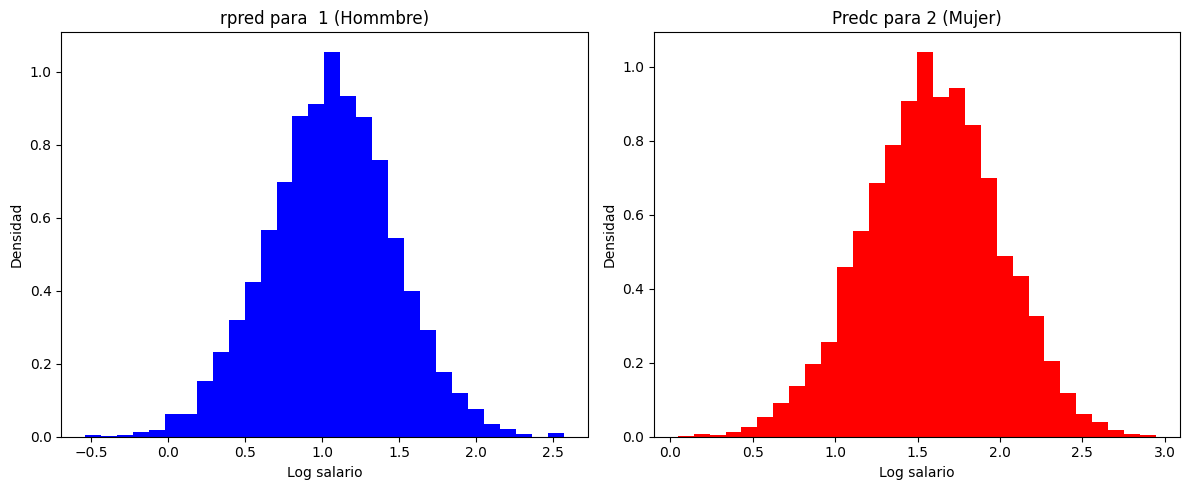

HDI 95% para Individual 1 (Hombre): [0.27045384 1.88252226]
HDI 95% para Individual 2 (Mujer): [0.77851993 2.35514241]


In [15]:
import arviz as az
import matplotlib.pyplot as plt

# saco las predicciones para los dos individuos específicos
predicciones_individual_1 = posterior_predictive.posterior_predictive['lwage_obs'][:, :, 0].values.flatten()
predicciones_individual_2 = posterior_predictive.posterior_predictive['lwage_obs'][:, :, 1].values.flatten()

# histogramas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(predicciones_individual_1, bins=30, density=True, color='blue')
plt.title("rpred para  1 (Hommbre)")
plt.xlabel("Log salario")
plt.ylabel("Densidad")

plt.subplot(1, 2, 2)
plt.hist(predicciones_individual_2, bins=30, density=True, color='red')
plt.title("Predc para 2 (Mujer)")
plt.xlabel("Log salario")
plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

# Calcular el HDI del 95% para cada individuo
hdi_individual_1 = az.hdi(predicciones_individual_1, hdi_prob=0.95)
hdi_individual_2 = az.hdi(predicciones_individual_2, hdi_prob=0.95)

print(f"HDI 95% para Individual 1 (Hombre): {hdi_individual_1}")
print(f"HDI 95% para Individual 2 (Mujer): {hdi_individual_2}")


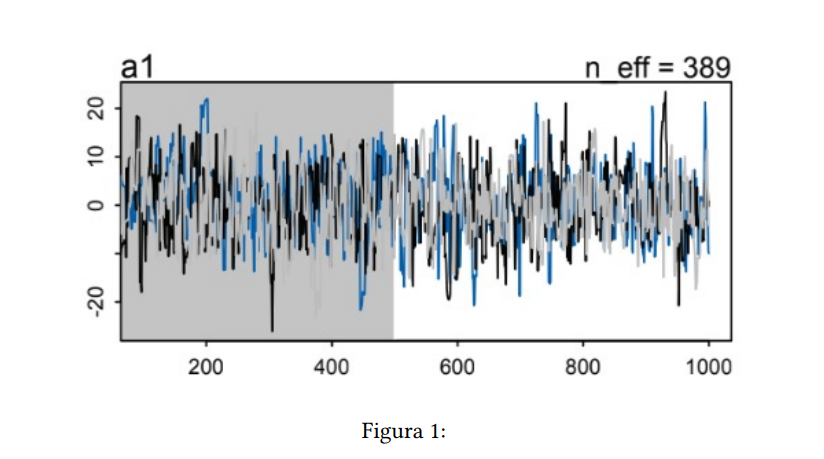

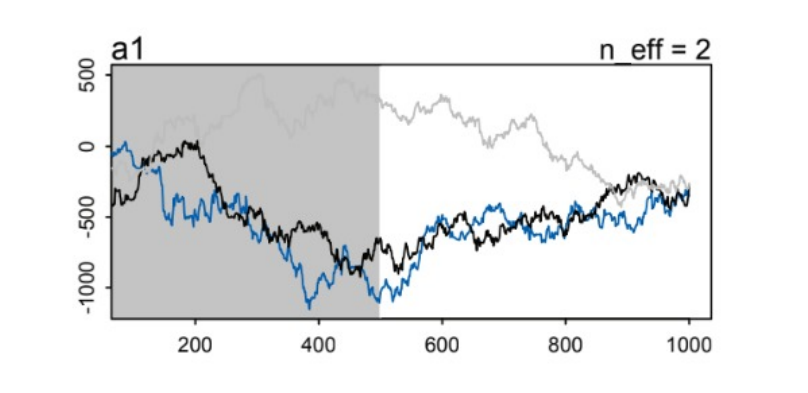


en la primera se puede ver un traceplot más estable en relacion a una posible media, a la vez que presenta oscilaciones lo que puede sugerir que hay mezcla de las cadenas. como no tienen una direccion especifica las cadenas llegan a una convergencia


En cambio en la segunda podemos observar una tendencia al final la segunda figura muestra una tendencia fuerte y una falta de estabilización en el valor promedio, lo cual indica que las cadenas no han convergido adecuadamente.  
